<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/Building_Agentic_Document_Understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building Agentic Document Understanding
A combination of OCR, Layout Detection, and VLM
1.   PaddleOCR: Text extraction and Layout LM for reading order
2.   Layout detection: To detect tables, chart and regions
3.   Agentic processing: Langchain agent with two special tools
*   Analyze chart: A VLM-based chart figure analysis
*   VLM-table: A VLM-table extraction

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
import os
# Control the logs
# os.environ["GLOG_minloglevel"] = "2" # 0=INFO, 1=WARNING, 2=ERROR, 3=FATAL
from dotenv import load_dotenv

In [3]:
_ = load_dotenv(override=True)

In [4]:
from PIL import Image
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass # Decorator for creating clean data structures
from typing import List, Dict, Any

In [ ]:
# Install all functionalities, such as document parsing, document understanding,
# document translation, and key information extraction
!pip install "paddleocr[all]"

In [ ]:
# You need to install paddlepaddle superatedly appart from paddlleocr
# or you could just !pip install "paddleocr[all]@git+https://github.com/PaddlePaddle/PaddleOCR.git"
# Make sure the paddle version matches to paddleOCR version
!pip install paddlepaddle==3.2.0

## 1. Text extraction with PaddleOCR + LayoutLM Ordering

In [7]:
from paddleocr import PaddleOCR

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


In [ ]:
# Initialize PaddleOCR
ocr = PaddleOCR(lang='en')

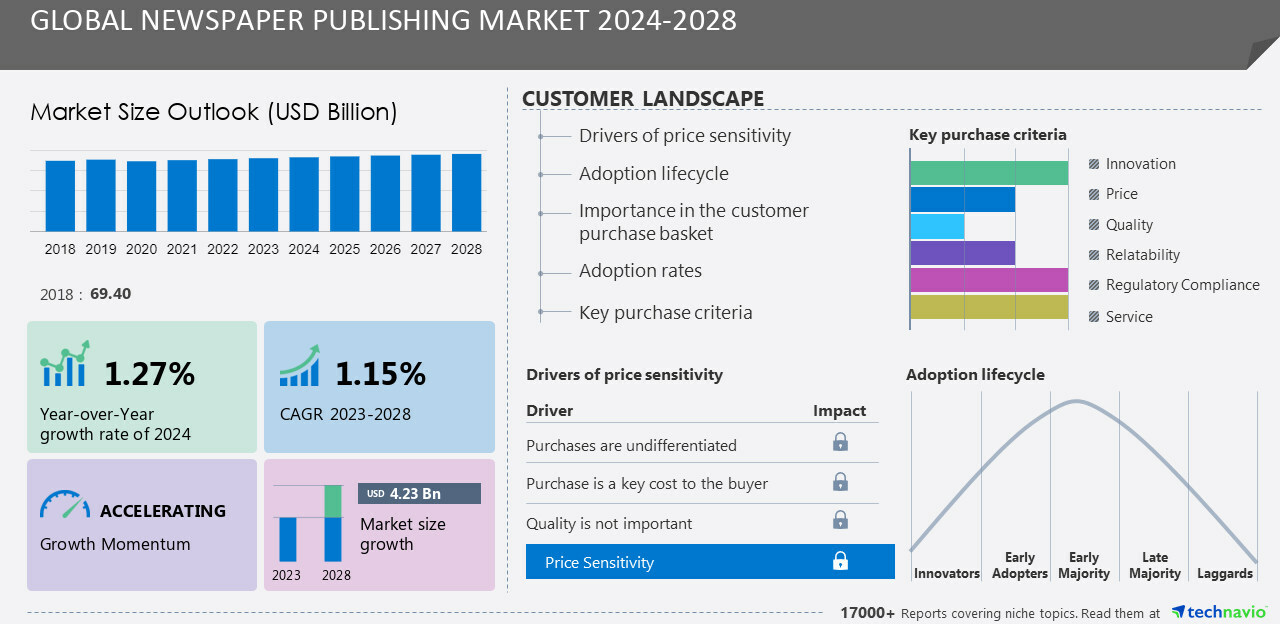

In [9]:
# Load image
image_path = 'Technavio_Infographic.jpg'
display(Image.open(image_path))

In [10]:
# Run OCR
result = ocr.predict(image_path)

In [11]:
page = result[0]
texts = page['rec_texts'] # recognized text string
scores = page['rec_scores'] # confidence scores
boxes = page['rec_polys'] # bounding box coordinates

print(f"Extracted {len(texts)} text regions")
print("\nFirst 10 regions:")
for text, score, box in list(zip(texts, scores, boxes))[:10]:
  coords = box.astype(int).tolist()
  print(f'- {text:40} | {score:.3f} | {coords}')


Extracted 50 text regions

First 10 regions:
- HING MARKET 2024-2028                    | 0.975 | [[420, 0], [756, 0], [756, 20], [420, 20]]
- Market Size Outlook (UsD Billion)        | 0.985 | [[0, 87], [403, 90], [403, 117], [0, 114]]
- CUSTOMER LANDSCAPE                       | 0.985 | [[531, 80], [785, 81], [785, 101], [531, 100]]
- Drivers of price sensitivity             | 0.978 | [[586, 117], [814, 119], [814, 142], [586, 140]]
- Key purchase criteria                    | 1.000 | [[931, 121], [1102, 119], [1102, 139], [931, 141]]
- Adoption lifecycle                       | 1.000 | [[583, 157], [747, 157], [747, 180], [583, 180]]
- %Innovation                              | 0.978 | [[1121, 149], [1222, 149], [1222, 169], [1121, 169]]
- Price                                    | 1.000 | [[1122, 177], [1185, 177], [1185, 202], [1122, 202]]
- Importance in the customer               | 1.000 | [[582, 193], [835, 196], [835, 222], [582, 219]]
- purchase basket                        

### Visualizing OCR Bounding Boxes

In [ ]:
processed_img = page['doc_preprocessor_res']['output_img']
img_plot = processed_img.copy()
show_text = False
for text, box in zip(texts, boxes):
  pts = np.array(box, dtype=int)
  cv2.polylines(img_plot, [pts], True, (0, 255, 0), 2)
  x, y = pts[0]
  if show_text:
    cv2.putText(img_plot, text, (x, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

  plt.figure(figsize=(8, 10))
  plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.title("Aligned Bounding Boxes (processed Image)")
  plt.show()

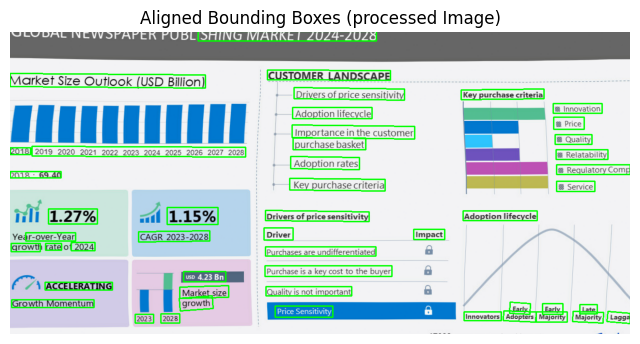

### Structuring OCR Results with a Dataclass
A clean type structure for each text region and convert 4 polygon format to a simple `[[x1, y1], [x2, y2]]`

In [ ]:
# Store OCR results in a structured format
@dataclass
class OCRRegion:
  text: str
  bbox: list #[[x1, y1], [x2, y2]]
  confidence: float
  @property
  def bbox_xyxy(self):
    """Return bbox as [x1, y1, x2, y2] format."""
    x_coords = [p[0] for p in self.bbox]
    y_coords = [p[1] for p in self.bbox]
    return [min(x_coords), min(y_coords), max(x_coords), max(y_coords)]

ocr_regions: List[OCRRegion] = []
for text, score, box in zip(texts, scores, boxes):
  ocr_regions.append(OCRRegion(
      text=text,
      bbox=box.astype(int).tolist(),
      confidence=score
  ))

  print(f'Stored {len(ocr_regions)} OCR regions')


### LayoutLM Reading Order

In [ ]:
# Setup the layoutreader project or just use the
# original https://github.com/microsoft/unilm/tree/master/layoutreader
# You might also import your layoutreader from your local machine if you want
!git clone https://github.com/ppaanngggg/layoutreader.git
!pip install -r layoutreader/requirements.txt

In [15]:
import sys
sys.path.append("layoutreader")

In [16]:
from transformers import LayoutLMv3ForTokenClassification
from v3.helpers import prepare_inputs, boxes2inputs, parse_logits

In [ ]:
# load LayoutReader model
print("loading pretrain LayoutReader model from huggingface...")
model_slug='hantian/layoutreader' #https://huggingface.co/hantian/layoutreader
layout_model = LayoutLMv3ForTokenClassification.from_pretrained(model_slug)
print('model loadded successfully!')

## Reading order detection function

In [18]:
def get_reading_order(ocr_regions):
  """
  Use LayoutReader to determine reading order of OCR regiions.
  Returns list of reading order positions fro each region index
  """
  # 1. Calculate image dimentions from bounding boxes(with padding)
  max_x = max_y = 0
  for region in ocr_regions:
    x1, y1, x2, y2 = region.bbox_xyxy
    max_x = max(max_x, x2)
    max_y = max(max_y, y2)

  image_width = max_x * 1.1 # add 10% padding
  image_height = max_y * 1.1

  # 2. Conver bboxes to LayoutReader format (normalized to 0-1000)
  boxes = []
  for region in ocr_regions:
    x1, y1, x2, y2 = region.bbox_xyxy
    # Normalize to 0-1000 range
    left = int((x1/image_width)*1000)
    top = int((y1/image_height)*1000)
    right = int((x2/image_width)*1000)
    bottom = int((y2/image_height)*1000)
    boxes.append([left, top, right, bottom])

  # 3. Prepare inputs
  inputs = boxes2inputs(boxes)
  inputs = prepare_inputs(inputs, layout_model)
  # 4. Run inference
  logits = layout_model(**inputs).logits.cpu().squeeze(0)
  # 5. Parse the model's outputs to get reading order
  reading_order = parse_logits(logits, len(boxes))

  return reading_order

In [19]:
# Get reading order
reading_order = get_reading_order(ocr_regions)
print(f'Reading order determined for {len(reading_order)} regions')
print(f'First 20 positions: {reading_order[:20]}')

Reading order determined for 50 regions
First 20 positions: [0, 1, 11, 12, 16, 19, 20, 25, 23, 27, 28, 29, 30, 2, 3, 5, 8, 9, 4, 6]


## Visualize the ther reading order

In [20]:
import matplotlib.patches as pathches
def visualize_reading_order(ocr_regions, image_array, reading_order, title="Reading order"):
  """
  Visualize OCR regions with their reading order numbers using matplotlib.
  """
  fig, ax = plt.subplots(1, figsize=(10, 14))
  ax.imshow(cv2.cvtColor(image_array, cv2.COLOR_RGB2BGR))

  # Create order mapping: index -> reading order position
  order_map = {i:order for i, order in enumerate(reading_order)}

  for i, region in enumerate(ocr_regions):
    bbox = region.bbox
    if bbox and len(bbox) >=4:
      # Draw polygon
      ax.add_patch(pathches.Polygon(bbox, linewidth=2,
                                   edgecolor='blue',
                                   facecolor='none', alpha=0.7))
      # Add reading order number at center
      xs = [p[0] for p in bbox]
      ys = [p[1] for p in bbox]
      ax.text(sum(xs)/len(xs), sum(ys)/len(ys),
              str(order_map.get(i, i)),
              fontsize=13, color='red',
              ha='center',
              va='center', fontweight='bold')
  ax.set_title(title, fontsize=14)
  ax.axis('off')
  plt.tight_layout()
  plt.show()



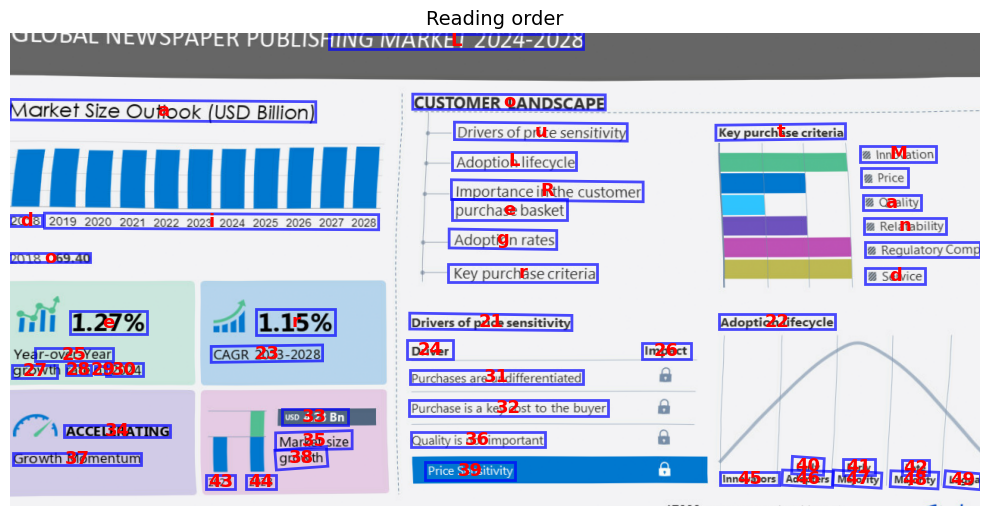

In [21]:
visualize_reading_order(ocr_regions, processed_img, reading_order='LaoutLM Reading order')

## Creating the Ordered Text Ouput

In [22]:
# Create ordered text content
def get_ordered_text(ocr_regions, reading_order):
  """
  Return OCR regions sorted by reading order
  with their text and confidence.
  """
  # 1. Create (reading_position, index, region) tuples and sort
  indexed_regions = [(reading_order[i],
                      i,
                      ocr_regions[i]) for i in range(len(ocr_regions))]

  # 2. Sort by reading position
  indexed_regions.sort(key=lambda x:x[0])

  # 3. Extract ordered text info
  ordered_text=[]
  for position, original_idx, region in indexed_regions:
    ordered_text.append({
        'position': position,
        'text': region.text,
        'confidence': region.confidence,
        'bbox': region.bbox_xyxy
    })
  return ordered_text

In [23]:
ordered_text = get_ordered_text(ocr_regions, reading_order)
ordered_text[:8]

[{'position': 0,
  'text': 'HING MARKET 2024-2028',
  'confidence': 0.9747035503387451,
  'bbox': [420, 0, 756, 20]},
 {'position': 1,
  'text': 'Market Size Outlook (UsD Billion)',
  'confidence': 0.9849843978881836,
  'bbox': [0, 87, 403, 117]},
 {'position': 2,
  'text': 'Relatability',
  'confidence': 0.9999103546142578,
  'bbox': [1127, 244, 1234, 264]},
 {'position': 3,
  'text': 'Adoption rates',
  'confidence': 0.9999449849128723,
  'bbox': [579, 258, 721, 285]},
 {'position': 4,
  'text': 'Service',
  'confidence': 0.9995631575584412,
  'bbox': [1128, 309, 1207, 330]},
 {'position': 5,
  'text': 'Regulatory Comp',
  'confidence': 0.9639080166816711,
  'bbox': [1128, 275, 1280, 295]},
 {'position': 6,
  'text': '1.27%',
  'confidence': 0.9345744848251343,
  'bbox': [79, 366, 180, 397]},
 {'position': 7,
  'text': '1.15%',
  'confidence': 0.9999723434448242,
  'bbox': [324, 363, 429, 398]}]

## 2. Layout Detection with PaddleOCR

In [24]:
from paddleocr import LayoutDetection

In [ ]:
# Initialize layout detection
layout_engine = LayoutDetection()

### Processing Document Layout

In [26]:
# processing document layout
def process_document(image_path):
  """
  Get layout regions from document.
  """
  layout_result = layout_engine.predict(image_path)

  regions = []
  for box in layout_result[0]['boxes']:
    regions.append({
        'label': box['label'],
        'score': box['score'],
        'bbox': box['coordinate'], # [x1, y1, x2, y2]
    })

  # sort by confidence
  regions = sorted(regions, key=lambda x: x['score'], reverse=True)
  return regions


In [27]:
layout_results = process_document(image_path)
print(f'Detected {len(layout_results)} layout regions:')
for r in layout_results:
  print(f' {r['label']:20} score: {r['score']:.3f} bbox: {[int(x) for x in r['bbox']]}')


Detected 8 layout regions:
 chart                score: 0.812 bbox: [26, 147, 486, 257]
 chart                score: 0.725 bbox: [902, 363, 1260, 584]
 chart                score: 0.623 bbox: [904, 144, 1263, 331]
 figure_title         score: 0.595 bbox: [27, 98, 398, 126]
 paragraph_title      score: 0.563 bbox: [27, 5, 736, 30]
 image                score: 0.550 bbox: [27, 319, 496, 592]
 text                 score: 0.542 bbox: [538, 120, 811, 324]
 footer               score: 0.522 bbox: [837, 603, 1266, 621]


In [28]:
layout_results[:5]

[{'label': 'chart',
  'score': 0.8120542764663696,
  'bbox': [np.float32(26.770287),
   np.float32(147.46967),
   np.float32(486.8169),
   np.float32(257.69666)]},
 {'label': 'chart',
  'score': 0.7251696586608887,
  'bbox': [np.float32(902.6635),
   np.float32(363.7755),
   np.float32(1260.4478),
   np.float32(584.0835)]},
 {'label': 'chart',
  'score': 0.6234702467918396,
  'bbox': [np.float32(904.8214),
   np.float32(144.9134),
   np.float32(1263.5647),
   np.float32(331.62192)]},
 {'label': 'figure_title',
  'score': 0.5950084328651428,
  'bbox': [np.float32(27.038422),
   np.float32(98.062965),
   np.float32(398.36182),
   np.float32(126.196945)]},
 {'label': 'paragraph_title',
  'score': 0.5631810426712036,
  'bbox': [np.float32(27.493553),
   np.float32(5.1905723),
   np.float32(736.47266),
   np.float32(30.966345)]}]

### Structuring Layout Results

In [29]:
@dataclass
class LayoutRegion:
  region_id: int
  region_type: str
  bbox: list #[x1, y1, x2, y2]
  confidence: float

# Store layout regions in structured format
layout_regions: List[LayoutRegion]=[]
for i, r in enumerate(layout_results):
  layout_regions.append(LayoutRegion(
    region_id=i,
    region_type=r['label'],
    bbox=[int(x) for x in r['bbox']],
    confidence=r['score']
  ))

In [30]:
print(f"strored {len(layout_regions)} layout regions")

strored 8 layout regions


In [31]:
layout_regions[:5]

[LayoutRegion(region_id=0, region_type='chart', bbox=[26, 147, 486, 257], confidence=0.8120542764663696),
 LayoutRegion(region_id=1, region_type='chart', bbox=[902, 363, 1260, 584], confidence=0.7251696586608887),
 LayoutRegion(region_id=2, region_type='chart', bbox=[904, 144, 1263, 331], confidence=0.6234702467918396),
 LayoutRegion(region_id=3, region_type='figure_title', bbox=[27, 98, 398, 126], confidence=0.5950084328651428),
 LayoutRegion(region_id=4, region_type='paragraph_title', bbox=[27, 5, 736, 30], confidence=0.5631810426712036)]

### Visualizing Layout Detection

In [32]:
# Visualize layout detection
from matplotlib import colormaps
def visualize_layout(image_path, layout_regions, min_confidence=0.5, title='Layout Detection'):
  """
  Visualize layout detection results using cv2 (same pattern as L2)
  """
  img = cv2.imread(image_path)
  img_plot = img.copy()

  # Get unique labels and generate colors
  labels = list(set(r.region_type for r in layout_regions))
  cmap=colormaps.get_cmap('tab20')
  color_map = {}
  for i, label in enumerate(labels):
    rgba = cmap(i%20)
    color_map[label] = (int(rgba[2]*255), int(rgba[1]*255), int(rgba[0]*255))

  for region in layout_regions:
    if region.confidence < min_confidence:
      continue

    color = color_map[region.region_type]
    x1, y1, x2, y2 = region.bbox

    # Draw rectangle
    pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=int)
    cv2.polylines(img_plot, [pts], True, color, 2)

    # Add label
    text = f"{region.region_id}: {region.region_type} ({region.confidence:.2f})"
    cv2.putText(img_plot, text, (x1, y1-8),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

  plt.figure(figsize=(12, 16))
  plt.imshow(cv2.cvtColor(img_plot, cv2.COLOR_BGR2RGB))
  plt.axis('off')
  plt.title(title)
  plt.show()
  return img_plot

In [ ]:
visualize_layout(image_path, layout_regions,
                 min_confidence=0.5, title="PaddleOCR Layout Detection")

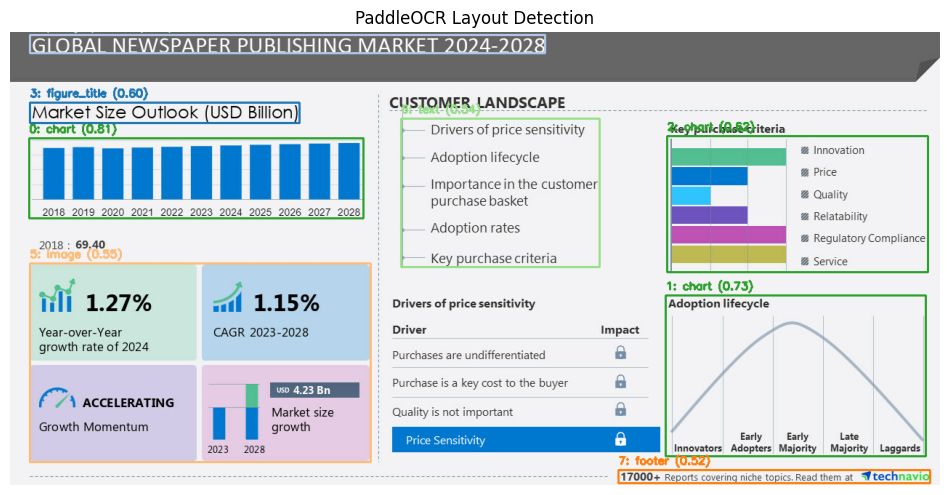

### Cropping Regions for Agent Tools
**Benefits**
 * Focused analysis -> the VLM only sees the relevent content
 * Reduce noise -> surrounding text does not interfere
 * Lower cost -> smaller image means lower api cost

 Even though the VLM is powerfull but they are not good at localization

In [34]:
import base64
from io import BytesIO

In [35]:
# Crop and save layout regions for agent tools
def crop_region(image, bbox, padding=10):
  """
  Crop a region from an image with optional padding.
  """
  x1, y1, x2, y2 = bbox
  x1 = max(0, x1 - padding)
  y1 = max(0, y1 - padding)
  x2 = min(image.width, x2 + padding)
  y2 = min(image.height, y2 + padding)
  return image.crop((x1, y1, x2, y2))

In [36]:
# Image to base64
def image_to_base64(img):
  """
  Convert PIL Image to base64 string.
  """
  buffer = BytesIO()
  img.save(buffer, format='PNG')
  return base64.b64encode(buffer.getvalue()).decode('utf-8')


In [37]:
# Load image for cropping
pil_image = Image.open(image_path)

In [38]:
# Store cropped regions in dictionary
region_images = {}
for region in layout_regions:
  cropped = crop_region(pil_image, region.bbox)
  region_images[region.region_id]={
      'image': cropped,
      'base64': image_to_base64(cropped),
      'type': region.region_type,
      'bbox': region.bbox
  }

print(f"Cropped {len(region_images)} regions")

Cropped 8 regions


In [39]:
# also store full image
full_image_base64 = image_to_base64(pil_image)

### Viewing Cropped Regions

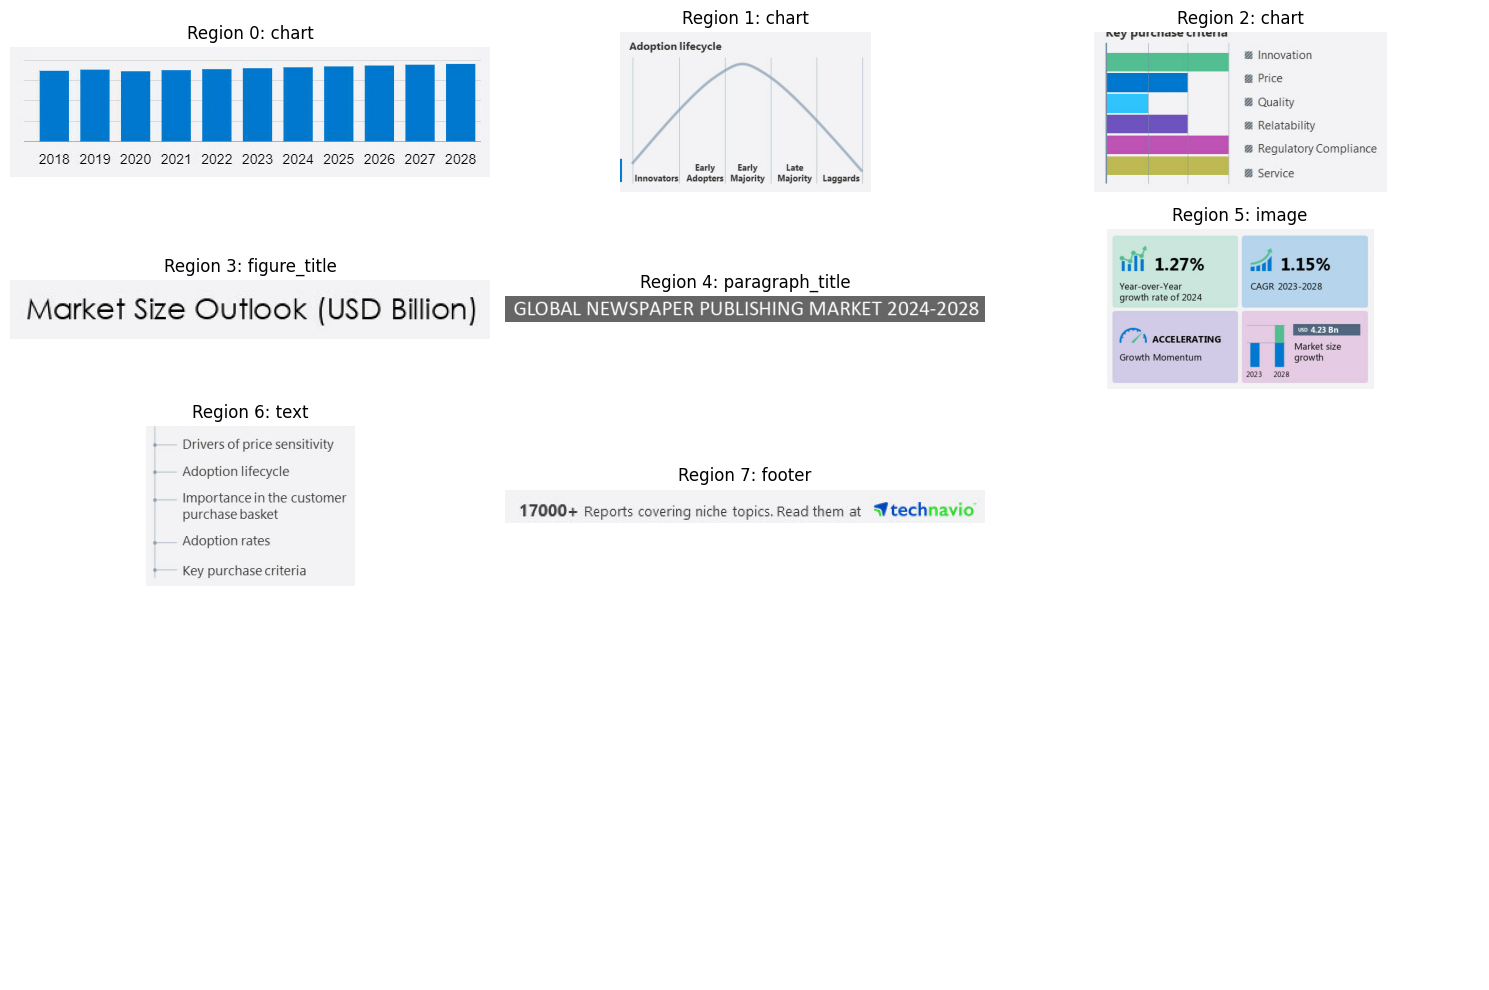

In [40]:
# Show Cropped regions
fig, axes = plt.subplots(5, 3, figsize=(15, 10))
axes = axes.flatten()
for i, (region_id, data) in enumerate(list(region_images.items())[:14]):
  axes[i].imshow(data['image'])
  axes[i].set_title(f"Region {region_id}: {data['type']}")
  axes[i].axis('off')

# Hide unused subplots
for j in range(i+1, len(axes)):
  axes[j].axis('off')

plt.tight_layout()
plt.show()

## 3. Agent Tools
1.   Analyze the chart using a VLM to interpret charts and images
2.   Analyze table also use VLM to extract structure data from tables

These will help us to optimize prompts for each content type, and will trune to json structure which is easy to process

In [41]:
from langchain.tools import tool
from langchain_openai import ChatOpenAI
from langchain.schema import HumanMessage

In [42]:
# Initialize VLM for tools
# vlm = ChatOpenAI(model='gpt-4o-min', temperature=0)
# Set up the OpenAI GPT model
if "OPENAI_API_KEY" not in os.environ:
    print("OPENAI_API_KEY environment variable is not set.")
    vlm = None
else:
    vlm = ChatOpenAI(
        # gpt-4o-mini: good for text cleanup, rewriting, formatting, speed
        # gpt-5-mini: good for reasoning-heavy tasks, planning, logic
        model="gpt-4o-mini",
        temperature=0 #  higher temperature more creative
    )
    print("OpenAI Chat model initialized.")

OpenAI Chat model initialized.


In [43]:
# Tool Prompts
CHART_ANALYSIS_PROMPT = """
You are a Chart Analysis specialist.

1. **Chart Type**: (line, bar, scatter, pie, etc.)
2. **Title**: (if visible)
3. **Axes**: X-axis label, Y-axis label, and tick values
4. **Data Points**: Key values (peaks, troughs, endpoints)
5. **Trends**: Overall pattern description
6. **Legend**: (if present)

Return a JSON object with this structure:
```json
{{
  "chart_type": "...",
  "title": "...",
  "x_axis": {{"label": "...", "ticks": [...]}},
  "y_axis": {{'label": "...", "ticks": [...]}},
  "key_data_points": [...],
  "trends": "...",
  "legend": [...]
}}
```
"""

In [44]:
TABLE_ANALYSIS_PROMPT = """
You are a Table Extraction specialist. Extract structured data from this table image.

1. **Identify Structure**:
  - Column headers, row labels, data cells
2. **Extract All Data**:
  - Preserve exact values and alignment
3. **Handle Special Cases**:
  - Merged cells, empty cells (mark as null), multi-line headers


Return a JSON object with this structure:
```json
{{
  "table_title": "...",
  "column_headers": ["header1", "header2", ...],
  "rows": [
    {{"row_label": "...", "values": [val1, val2, ...]}},
    ...
  ],
  "notes": "any footnotes or source info"
}}
```
"""

### VLM Helper Function
Handle the mechanics of calling VLM with an image, which create a multi model
message containing both text prompt and the base64 encoded image and return the model response


In [45]:
def call_vlm_with_image(image_base64: str, prompt:str) -> str:
  """Call VLM with an image and prompt."""
  message = HumanMessage(
      content=[
          {"type": "text", "text": prompt},
          {
              "type": "image_url",
              "image_url": {'url':f"data:image/png;base64,{image_base64}"}
          }
      ]
  )
  response = vlm.invoke([message])
  return response.content

### Creating the AnalyzeChart Tool


In [46]:
@tool
def AnalyzeChart(region_id:int) -> str:
  """
  Analyze a chart or figure region using VLM.
  Use this tool when you need to extract data from charts, graphs, or figures

  Args:
      region_id: The ID of the layout region to analyze (must be a chart/figure type)

  Returns:
      JSON string with chart type, axes, data points, and trends
  """
  if region_id not in region_images:
    return f"Error: Region {region_id} not found. Available regions: {list(region_images.keys())}"

  region_data = region_images[region_id]

  if region_data['type'] not in ['chart', 'figure']:
    return f"Warning: Region {region_id} is type '{region_data['type']}', not a chart or figure proceeding anyways."

  result = call_vlm_with_image(region_data['base64'], CHART_ANALYSIS_PROMPT)

  return result

### Creating the AnalyzTable Tool

In [77]:
@tool
def AnalyzeTable(region_id: int) -> str:
  """
  Extract structured data from a table region using VLM.
  Use this tool when you need to extract tabular data with headers and rows.

  Args:
    region_id: The ID of the layout region to analyze(must be a table type)

  Returns:
    JSON string with table headers, rows, and any notes
  """
  if region_id not in region_images:
    return f"Error: Region {region_id} not found. Available regions: {list(region_images.keys())}"

  region_data = region_images[region_id]

  if region_data['type'] != 'table':
    return f"Warning: Region {region_id} is type '{region_data['type']}', not a table procceding anyways"

  result = call_vlm_with_image(region_data['base64'], TABLE_ANALYSIS_PROMPT)
  return result

### Testing the Chart Analysis Tool

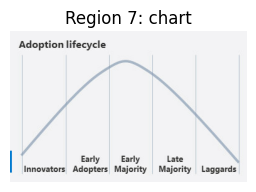

In [78]:
plt.figure(figsize=(3, 2))
specific_region = region_images[1]
plt.imshow(specific_region['image'])
plt.title(f"Region {region_id}: {specific_region['type']}")
plt.axis('off')
plt.tight_layout()
plt.show()

In [79]:
# Test the tools
chart_regions = [r for r in layout_regions if r.region_type in ['chart', 'figure']]
if chart_regions:
  test_result = AnalyzeChart.invoke({'region_id': chart_regions[1].region_id})
  print(f'Chart analysis result: \n{test_result}')
else:
  print('No chart regions found')

Chart analysis result: 
```json
{
  "chart_type": "line",
  "title": "Adoption lifecycle",
  "x_axis": {
    "label": "Adoption Stages",
    "ticks": ["Innovators", "Early Adopters", "Early Majority", "Late Majority", "Laggards"]
  },
  "y_axis": {
    "label": "Adoption Rate",
    "ticks": [0, 25, 50, 75, 100]
  },
  "key_data_points": [
    {"stage": "Innovators", "value": 10},
    {"stage": "Early Adopters", "value": 40},
    {"stage": "Early Majority", "value": 70},
    {"stage": "Late Majority", "value": 40},
    {"stage": "Laggards", "value": 10}
  ],
  "trends": "The adoption rate increases to a peak during the Early Majority stage and then declines as it reaches the Laggards.",
  "legend": []
}
```


### Testing the Table Analysis Tool

In [80]:
# Test table tool
table_regions = [r for r in layout_regions if r.region_type == 'table']
if table_regions:
  test_result = AnalyzeTable.invoke({"region_id": table_regions[0].region_id})
  print(f"Table analysis result: \n{test_result[:500]}...")
else:
  print("No table regions found")

No table regions found


##4. LangChain Agent

How does this Agent works?
1. The agent will receive a question about the document
2. It raises the system prompt containing all the OCR text and layout info
3. It will decide whether or not to they will need to answer from text alone or using other tools
4. For visual content like Chart and Table it will call a proper tool
5. It will combine all the information into a coherent response

### Just examing the Data Strucures

In [81]:
ordered_text[0]

{'position': 0,
 'text': 'HING MARKET 2024-2028',
 'confidence': 0.9747035503387451,
 'bbox': [420, 0, 756, 20]}

In [82]:
layout_regions[0]

LayoutRegion(region_id=0, region_type='chart', bbox=[26, 147, 486, 257], confidence=0.8120542764663696)

### Formatting Context for the Agent

In [83]:
# Prepare context for the agent
def format_ordered_text(ordered_text, max_items=50):
  """Format ordered text for the system prompt."""
  lines = []
  for item in ordered_text[:max_items]:
    lines.append(f"[{item['position']}] {item['text']}")

  if len(ordered_text)>max_items:
    lines.append(f"... and {len(ordered_text) - max_items} more text regions")

  return "\n".join(lines)


In [84]:
# Format layout regions
def format_layout_regions(layout_regions):
  """Format layout regions for the system prompt."""
  lines = []
  for region in layout_regions:
    lines.append(f" - Region {region.region_id}: {region.region_type} (confidence: {region.confidence:.3f})")
  return "\n".join(lines)

In [85]:
ordered_text[:1]

[{'position': 0,
  'text': 'HING MARKET 2024-2028',
  'confidence': 0.9747035503387451,
  'bbox': [420, 0, 756, 20]}]

In [86]:
layout_regions[:1]

[LayoutRegion(region_id=0, region_type='chart', bbox=[26, 147, 486, 257], confidence=0.8120542764663696)]

In [87]:
# Create the formated strings
ordered_text_str = format_ordered_text(ordered_text)
layout_regions_str = format_layout_regions(layout_regions)

In [88]:
ordered_text_str[0: 200]

'[0] HING MARKET 2024-2028\n[1] Market Size Outlook (UsD Billion)\n[2] Relatability\n[3] Adoption rates\n[4] Service\n[5] Regulatory Comp\n[6] 1.27%\n[7] 1.15%\n[8] 2018: 69.40\n[9] Key purchase criteria\n[10] D'

In [89]:
layout_regions_str[0: 200]

' - Region 0: chart (confidence: 0.812)\n - Region 1: chart (confidence: 0.725)\n - Region 2: chart (confidence: 0.623)\n - Region 3: figure_title (confidence: 0.595)\n - Region 4: paragraph_title (confide'

### Create the System Prompt
The foundation of our agent behavior

In [90]:
# System prompt for the agent
SYSTEM_PROMPT = f"""
You are a Document Intelligence Agent.
You analyze documents by combining OCR text with visual analysis tools.

## Document Text (in reading order)
The following text was extracted using OCR and ordered using LayoutLM.

{ordered_text_str}

## Document Layout Regions
The following regions were detected in the document:

{layout_regions_str}

## Your Tools
- **AnalyzeChart(region_id)**:
  - Use for chart/figure regions to extract data points, axes, and trends
- **AnalyzeTable(region_id)**:
  - Use for table regions to extract structured tabular data

## Instructions
1. For TEXT regions:
    - Use the OCR text provided above (it's already extracted)
2. For TABLE regions:
    - Use the AnalyzeTable tool to get structured data
3. For CHART/FIGURE regions:
    - Use the AnalyzeChart tool to extract visual data

When answering questions about the document,
use the appropriate tools to get accurate information
"""
print(f"Total length: {len(SYSTEM_PROMPT)} characters")

Total length: 2165 characters


### Assembling the agent
Let's put all togheter

In [91]:
# Initialize the agent (using LangChain 0.1.x API)
tools = [AnalyzeChart, AnalyzeTable]

# LLM for the agent
if "OPENAI_API_KEY" not in os.environ:
    agent_llm = None
else:
    agent_llm = ChatOpenAI(
        model="gpt-4o-mini",
        temperature=0 #  higher temperature more creative
    )
    print("Agent LLM initialized.")

Agent LLM initialized.


In [92]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import create_tool_calling_agent
from langchain.agents import AgentExecutor
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", SYSTEM_PROMPT),
        ("user", "{input}"),
        MessagesPlaceholder(variable_name="agent_scratchpad")
    ]
)

In [93]:
# Create a proper tool-calling agent
agent = create_tool_calling_agent(agent_llm, tools, prompt)

In [102]:
# Set up the AgentExecutor to run the tool-enabled loop
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=False)

### Test 1: Document Overview

In [ ]:
# Test the agent with a simple question
response = agent_executor.invoke({
    "input": "What types of content are in this document?"
      "List the main scetions.",
})
print(response['output'])

### Test 2: Table Data Extraction

In [ ]:
# Test with table extraction
response_t = agent_executor.invoke({
    "input": "Extract the data from the table in this document."
    "Return it in a structured format."
})
print(response_t['output'])

### Test 3: Chart Analysis

In [103]:
# Test with chart analysis
response_ch = agent_executor.invoke({
    "input": "Analyze the chart/figure in this document."
    "What trends does it show?"
})
print(response_ch['output'])

The document contains three charts, each showing different trends:

1. **Bar Chart (Yearly Data)**:
   - **Chart Type**: Bar
   - **Trends**: The chart shows a consistent bar height across the years from 2018 to 2028, indicating stable values over time. There are no significant fluctuations in the data presented.

2. **Line Chart (Adoption Lifecycle)**:
   - **Chart Type**: Line
   - **Trends**: The adoption rate increases to a peak during the Early Majority stage and then declines as it reaches the Laggards. This suggests that most users adopt the product during the Early Majority phase, while the Laggards show a significantly lower adoption rate.

3. **Bar Chart (Key Purchase Criteria)**:
   - **Chart Type**: Bar
   - **Trends**: Quality is identified as the most important criterion for purchases, followed by Innovation and Price. Other criteria such as Relatability, Regulatory Compliance, and Service are considered less important in comparison.

These trends provide insights into ma